Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
  - Registered boundary 'wall': 21 segments
  - Registered boundary 'upstream': 5 segments
  - Registered boundary 'building': 3252 segments
Sampling 100000 interior points...
Found boundary types: ['wall', 'upstream', 'building']
  - Sampling 'wall' (20000 points)...
  - Sampling 'upstream' (20000 points)...
  - Sampling 'building' (20000 points)...
Generating plot...
Domain Bounds: X[560619.6, 561358.9], Y[99683.6, 100382.9]
Plot saved to check_mesh_density.png


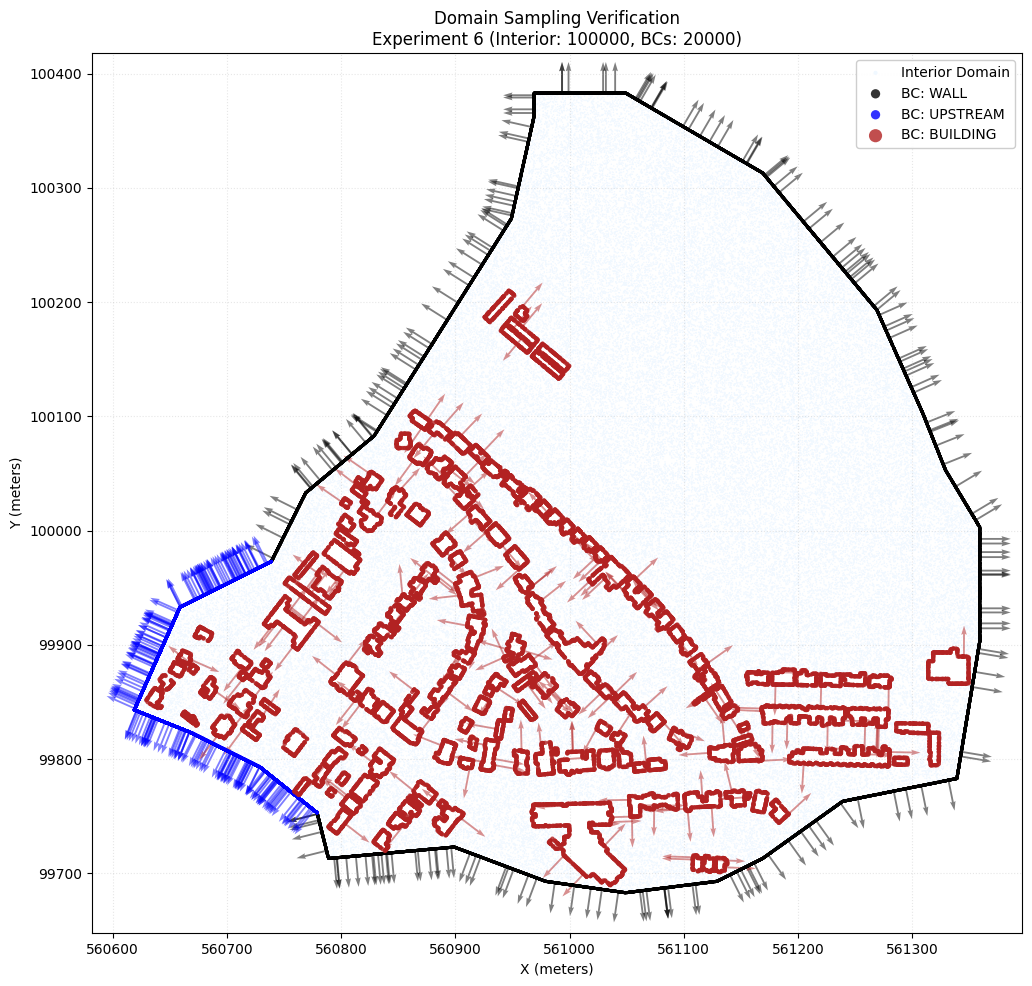

In [10]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

# --- Setup Paths ---
# Add project root to path so we can import src
try:
    # Assuming this script is in scripts/ or similar relative to root
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Fallback for interactive environments (notebooks/REPL)
    project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# --- Configuration ---
# Set JAX to use CPU for plotting to avoid OOM on small GPUs/rendering
jax.config.update("jax_platform_name", "cpu")

import src.config
src.config.DTYPE = jnp.float32

from src.data import IrregularDomainSampler

# Path to your artifacts (ensure this matches where you ran the preprocess script)
ARTIFACTS_PATH = os.path.join(project_root, "/workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz")

def main():
    if not os.path.exists(ARTIFACTS_PATH):
        print(f"Error: Artifacts not found at {ARTIFACTS_PATH}")
        print("Please run scripts/preprocess_irregular.py first.")
        return

    print(f"Loading sampler artifacts from: {ARTIFACTS_PATH}")
    
    # Initialize Sampler
    # The updated IrregularDomainSampler automatically detects keys like 'bc_building', 'bc_upstream'
    try:
        sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    except Exception as e:
        print(f"Failed to initialize sampler: {e}")
        return
    
    # Setup JAX keys
    key = jax.random.PRNGKey(42)
    k_int, k_bnd = jax.random.split(key)

    # --- Sampling Configuration ---
    # High density numbers for "good density" visualization
    N_INTERIOR = 100_000
    N_BOUNDARY = 20_000
    
    # 1. Sample Interior
    print(f"Sampling {N_INTERIOR} interior points...")
    # t_bounds are required by the API but irrelevant for spatial 2D plotting
    interior_pts = sampler.sample_interior(k_int, n_points=N_INTERIOR, t_bounds=(0, 1))
    
    # 2. Sample All Boundaries
    bnd_samples = {}
    available_boundaries = list(sampler.boundaries.keys())
    print(f"Found boundary types: {available_boundaries}")
    
    for label in available_boundaries:
        k_bnd, subkey = jax.random.split(k_bnd)
        print(f"  - Sampling '{label}' ({N_BOUNDARY} points)...")
        # Determine specific density based on label if needed, otherwise uniform
        n_b = N_BOUNDARY
        
        # Sample
        pts = sampler.sample_boundary(subkey, n_points=n_b, t_bounds=(0, 1), boundary_type=label)
        bnd_samples[label] = pts

    # --- Plotting ---
    print("Generating plot...")
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Plot Interior
    # Use s=0.5 or s=1 with low alpha to visualize density gradients if they exist
    ax.scatter(interior_pts[:, 0], interior_pts[:, 1], 
               s=1, c='aliceblue', edgecolors='none', alpha=1.0, 
               label='Interior Domain', rasterized=True)
    
    # Plot Boundaries with distinct colors
    # Define a color map for common types
    color_map = {
        'wall': 'black',
        'building': 'firebrick',
        'upstream': 'blue',
        'downstream': 'green',
        'inflow': 'blue',
        'outflow': 'green'
    }
    fallback_colors = ['purple', 'orange', 'cyan', 'magenta']
    
    for i, (label, pts) in enumerate(bnd_samples.items()):
        if pts.shape[0] == 0:
            continue
            
        color = color_map.get(label, fallback_colors[i % len(fallback_colors)])
        marker = '.'
        
        # Make buildings stand out
        size = 10 if label == 'building' else 5
        zorder = 10 if label == 'building' else 5
        
        ax.scatter(pts[:, 0], pts[:, 1], 
                   s=size, c=color, label=f"BC: {label.upper()}", 
                   alpha=0.8, edgecolors='none', zorder=zorder)

        # Plot normal vectors for a subset of points (to verify orientation)
        # pts has shape (N, 5) -> [x, y, t, nx, ny]
        if pts.shape[1] >= 5:
            step = max(1, len(pts) // 200) # Plot ~200 arrows per boundary
            subset = pts[::step]
            ax.quiver(subset[:, 0], subset[:, 1], subset[:, 3], subset[:, 4],
                      color=color, scale=30, width=0.002, alpha=0.5)

    ax.set_aspect('equal')
    ax.set_title(f"Domain Sampling Verification\nExperiment 6 (Interior: {N_INTERIOR}, BCs: {N_BOUNDARY})")
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Y (meters)")
    ax.legend(loc='upper right', framealpha=0.95, markerscale=3)
    ax.grid(True, linestyle=':', alpha=0.3)
    
    # Add coordinates info
    x_min, x_max = interior_pts[:, 0].min(), interior_pts[:, 0].max()
    y_min, y_max = interior_pts[:, 1].min(), interior_pts[:, 1].max()
    print(f"Domain Bounds: X[{x_min:.1f}, {x_max:.1f}], Y[{y_min:.1f}, {y_max:.1f}]")
    
    out_file = "check_mesh_density.png"
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {out_file}")
    plt.show()

if __name__ == "__main__":
    main()

Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
  - Registered boundary 'wall': 21 segments
  - Registered boundary 'upstream': 5 segments
  - Registered boundary 'building': 3252 segments
Sampling 50,000 PDE points...
Loading buildings from /workspaces/swe-pinn/data/experiment_6/Buildings_cleaned.shp...
Generating verification plot...
Number of PDE samples generated: 50000
Sample X range: 560619.88 to 561359.00
Sample Y range: 99683.44 to 100382.80
Verification plot saved to check_pde_voids_fixed.png


/tmp/ipykernel_10610/4121183476.py:75: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right")


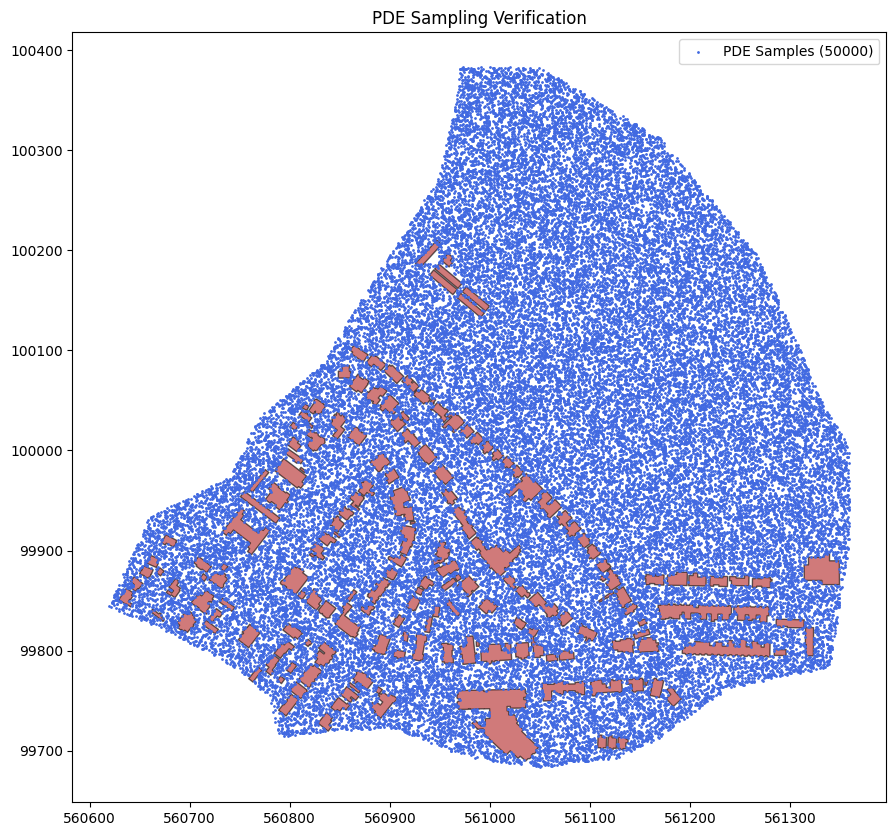

In [15]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import jax
import jax.numpy as jnp
from shapely.geometry import Point

# --- Setup Paths ---
try:
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import src.config
src.config.DTYPE = jnp.float32
from src.data import IrregularDomainSampler

# --- CORRECTED PATHS ---
# Using the absolute paths you provided directly
ARTIFACTS_PATH = "/workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz"
BUILDINGS_PATH = "/workspaces/swe-pinn/data/experiment_6/Buildings_cleaned.shp"

def main():
    # 1. Initialize Sampler
    if not os.path.exists(ARTIFACTS_PATH):
        print(f"Error: Artifacts not found at {ARTIFACTS_PATH}")
        print("Did you run 'scripts/preprocess_irregular.py' with the --buildings flag yet?")
        return
    
    print(f"Loading sampler artifacts from: {ARTIFACTS_PATH}")
    sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    
    # 2. Sample PDE Points (Interior)
    print("Sampling 50,000 PDE points...")
    key = jax.random.PRNGKey(0)
    # Sample interior points (time is irrelevant for this spatial check)
    pde_samples = sampler.sample_interior(key, n_points=50000, t_bounds=(0, 1))
    pde_xy = pde_samples[:, :2] # Extract (x, y)
    
    # 3. Load Buildings for Verification
    if not os.path.exists(BUILDINGS_PATH):
        print(f"Error: Buildings file not found at {BUILDINGS_PATH}")
        return

    print(f"Loading buildings from {BUILDINGS_PATH}...")
    try:
        buildings_gdf = gpd.read_file(BUILDINGS_PATH)
    except Exception as e:
        print(f"Could not load buildings for verification: {e}")
        return

# 4. Plotting Verification
    print("Generating verification plot...")
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # A. Plot Buildings (Red Voids)
    buildings_gdf.plot(ax=ax, color='firebrick', alpha=0.6, edgecolor='black', label='Buildings (Obstacles)')
    
    # B. Plot PDE Samples (Dark Blue)
    # Changed from 'aliceblue' to 'blue' and s=0.5 to s=1.0 for visibility
    pts_np = np.array(pde_xy)
    if len(pts_np) > 0:
        ax.scatter(pts_np[:, 0], pts_np[:, 1], s=1.0, c='royalblue', label=f'PDE Samples ({len(pts_np)})')
    else:
        print("WARNING: PDE Sample array is empty!")

    # C. Formatting
    ax.set_title("PDE Sampling Verification")
    ax.set_aspect('equal')
    ax.legend(loc="upper right")
    
    # Print stats to terminal to confirm data exists
    print(f"Number of PDE samples generated: {len(pts_np)}")
    if len(pts_np) > 0:
        print(f"Sample X range: {pts_np[:,0].min():.2f} to {pts_np[:,0].max():.2f}")
        print(f"Sample Y range: {pts_np[:,1].min():.2f} to {pts_np[:,1].max():.2f}")
    
    output_file = "check_pde_voids_fixed.png"
    plt.savefig(output_file, dpi=150)
    print(f"Verification plot saved to {output_file}")
    plt.show()

if __name__ == "__main__":
    main()

Project Root: /workspaces/swe-pinn
Data Path: /workspaces/swe-pinn/data/experiment_6
Artifacts Path: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
Loading domain geometry...
Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
  - Registered boundary 'wall': 21 segments
  - Registered boundary 'upstream': 5 segments
  - Registered boundary 'building': 3252 segments
Loading weights from: /workspaces/swe-pinn/models/2026-02-10_17-41_experiment_6/2026-02-10_17-41_experiment_6_params.pkl
Generating plot for t = 0.0s...


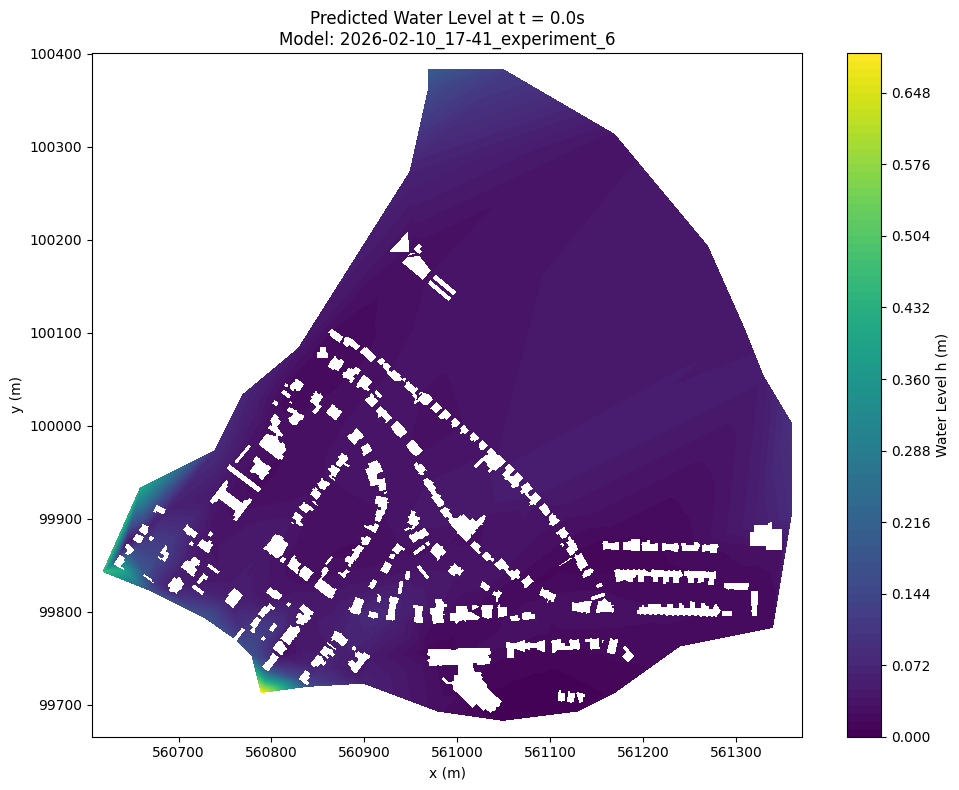

Generating plot for t = 3600.0s...


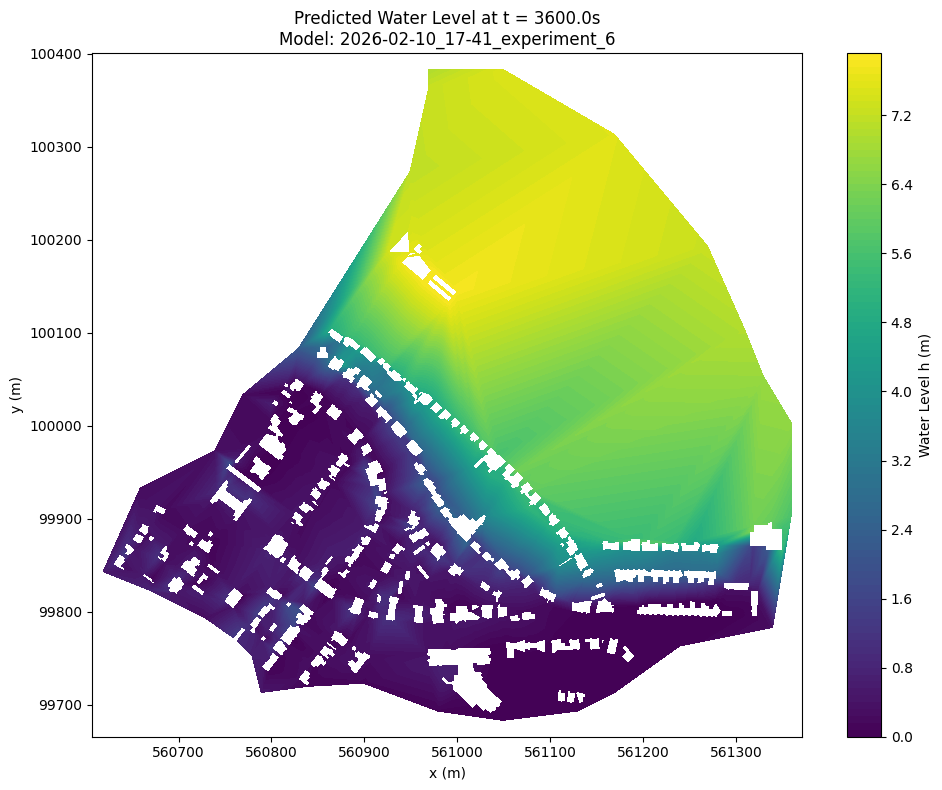

Generating plot for t = 21600.0s...


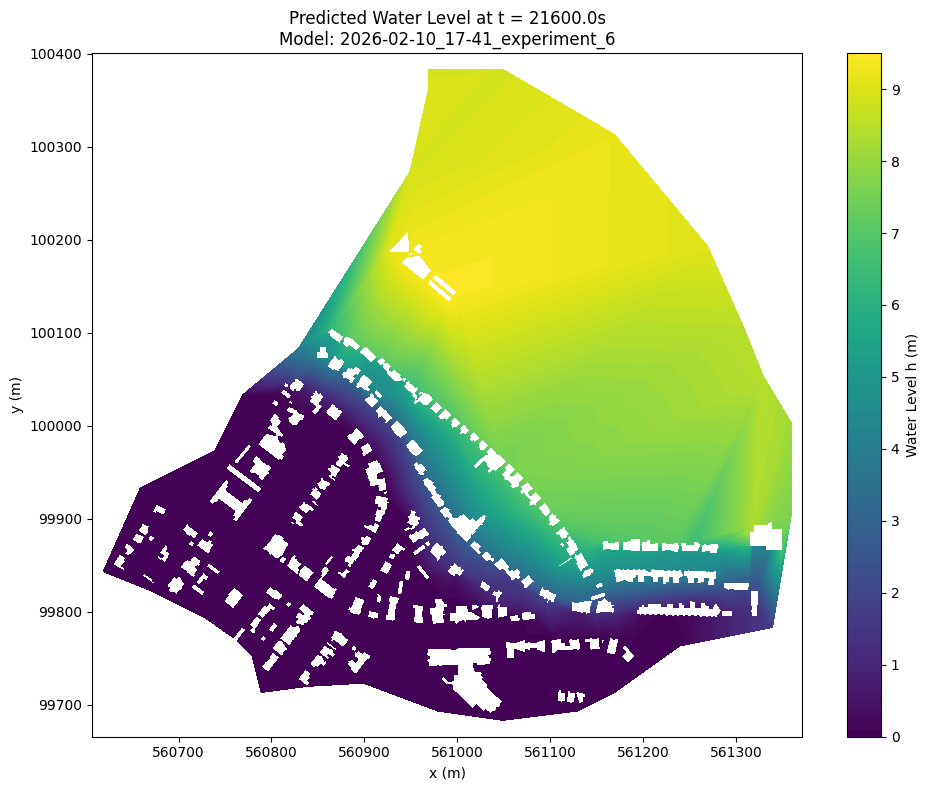

Generating plot for t = 10800.0s...


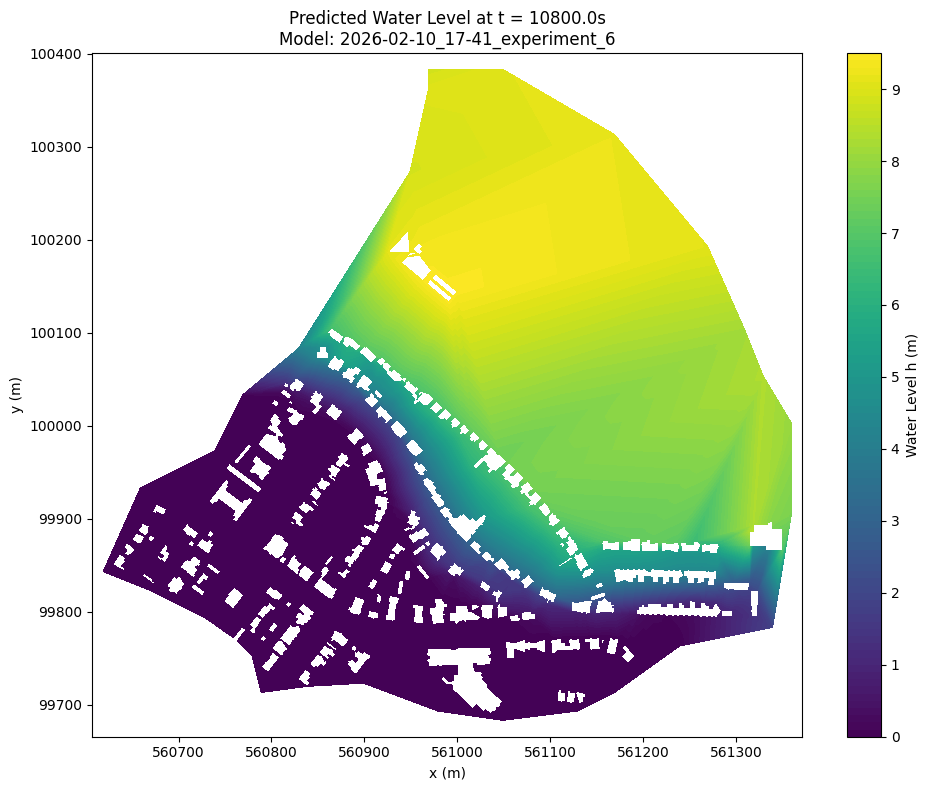

Visualization complete.


In [7]:
import sys
import os
import pickle
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from flax.core import FrozenDict

# --- 1. Setup Paths & Directories ---
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import load_config
from src.models import init_model
from src.data import IrregularDomainSampler

# --- 2. User Definitions ---
TRIAL_DIR_NAME = "2026-02-10_17-41_experiment_6" 
CONFIG_NAME = "experiment_6.yaml"
PLOT_TIMESTEPS = [0.0, 3600.0, 21600.0, 10800.0] 

# --- 3. Load Configuration FIRST ---
# We load config first to know which scenario (data folder) to use
config_path = os.path.join(project_root, "configs", CONFIG_NAME)
if not os.path.exists(config_path):
    raise FileNotFoundError(f"Config file not found: {config_path}")

cfg_dict = load_config(config_path)

# --- 4. Construct Data Paths Correctly ---
# Use the scenario name from config to find the data folder
scenario_name = cfg_dict.get('scenario', 'experiment_6')
base_data_path = os.path.join(project_root, "data", scenario_name)

# Check for artifacts
artifacts_path = os.path.join(base_data_path, "domain_artifacts.npz")
if not os.path.exists(artifacts_path):
    artifacts_path = os.path.join(base_data_path, "domain.npz")
    
if not os.path.exists(artifacts_path):
    raise FileNotFoundError(f"Domain artifacts not found at: {artifacts_path}")

print(f"Project Root: {project_root}")
print(f"Data Path: {base_data_path}")
print(f"Artifacts Path: {artifacts_path}")

# --- 5. Initialize Domain & Update Config ---
print(f"Loading domain geometry...")
domain_sampler = IrregularDomainSampler(artifacts_path)

# Calculate Domain Extent from the loaded sampler
all_coords = domain_sampler.tri_coords.reshape(-1, 2)
min_vals = jnp.min(all_coords, axis=0)
max_vals = jnp.max(all_coords, axis=0)

x_min, y_min = float(min_vals[0]), float(min_vals[1])
x_max, y_max = float(max_vals[0]), float(max_vals[1])

if 'domain' not in cfg_dict: cfg_dict['domain'] = {}
cfg_dict['domain'].update({
    'lx': x_max - x_min,
    'ly': y_max - y_min,
    'x_min': x_min, 'x_max': x_max,
    'y_min': y_min, 'y_max': y_max
})

# Freeze config for model init
cfg = FrozenDict(cfg_dict)

# --- 6. Initialize Model & Load Weights ---
model_dir = os.path.join(project_root, "models", TRIAL_DIR_NAME)

# Check for common weight filenames
potential_weight_files = [
    "model_weights.pkl", 
    f"{TRIAL_DIR_NAME}_params.pkl",
    "params.pkl"
]
weights_path = None
for f_name in potential_weight_files:
    p = os.path.join(model_dir, f_name)
    if os.path.exists(p):
        weights_path = p
        break

if not weights_path:
    raise FileNotFoundError(f"Could not find weight file in {model_dir}. Checked: {potential_weight_files}")

print(f"Loading weights from: {weights_path}")

# Init Model Structure
key = jax.random.PRNGKey(0)
try:
    models_module = __import__("src.models", fromlist=[cfg["model"]["name"]])
    model_class = getattr(models_module, cfg["model"]["name"])
except ImportError:
    raise ImportError(f"Could not import model {cfg['model']['name']}")

model, _ = init_model(model_class, key, cfg)

# Load Parameters
with open(weights_path, 'rb') as f:
    params = pickle.load(f)

# --- 7. Plotting ---
flat_coords = domain_sampler.tri_coords.reshape(-1, 2)
x_flat = flat_coords[:, 0]
y_flat = flat_coords[:, 1]

num_triangles = domain_sampler.tri_coords.shape[0]
triangles_indices = np.arange(num_triangles * 3).reshape(num_triangles, 3)
triangulation = tri.Triangulation(x_flat, y_flat, triangles_indices)

for t_val in PLOT_TIMESTEPS:
    print(f"Generating plot for t = {t_val}s...")
    t_input = jnp.full_like(x_flat, t_val)
    inputs = jnp.stack([jnp.array(x_flat), jnp.array(y_flat), t_input], axis=-1)
    
    U_pred = model.apply(params, inputs, train=False)
    h_pred = np.array(U_pred[..., 0])
    
    plt.figure(figsize=(10, 8))
    contour = plt.tricontourf(triangulation, h_pred, levels=100, cmap='viridis')
    plt.colorbar(contour, label='Water Level h (m)')
    plt.title(f"Predicted Water Level at t = {t_val}s\nModel: {TRIAL_DIR_NAME}")
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

print("Visualization complete.")

Loading domain info from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
  - Registered boundary 'wall': 21 segments
  - Registered boundary 'upstream': 5 segments
  - Registered boundary 'building': 3252 segments
Domain: X[560619.00, 561359.00], Y[99683.00, 100383.00]
Dimensions: lx=740.00, ly=700.00
Model weights loaded from /workspaces/swe-pinn/models/2026-02-12_01-48_experiment_6_IS_Weighted/2026-02-12_01-48_experiment_6_IS_Weighted_params.pkl

--- Processing Timestep t=21600.0s ---
Loading validation tensor...
Found 10758 points for t=21600.0s
Loading 2D Zones mesh...
Performing spatial join (Points inside Mesh Elements)...
Matched 5004 mesh elements with validation points.
Running PINN inference...


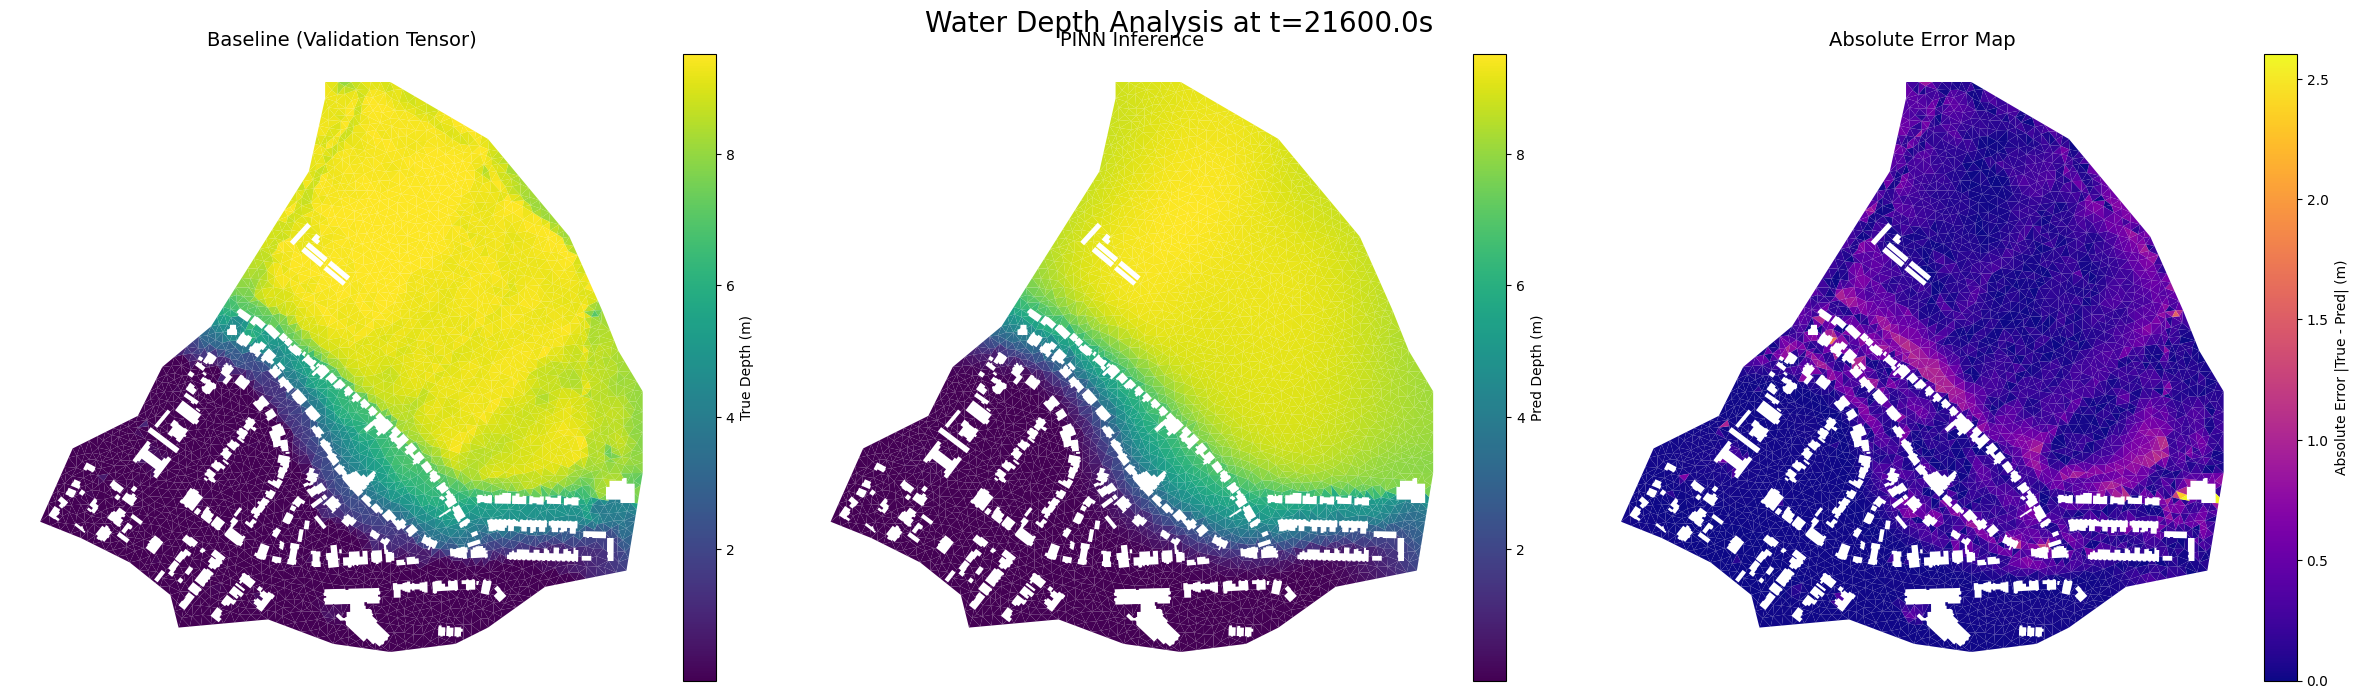

In [ ]:
import sys
import os
import pickle
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from flax.core import FrozenDict
import geopandas as gpd
from shapely.geometry import Point
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- 1. Setup Paths & Directories ---
# Adjust project root to point to the correct location relative to this script
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import local modules
try:
    from src.config import load_config
    from src.models import init_model
    from src.data import IrregularDomainSampler
except ImportError as e:
    print(f"Error importing src modules: {e}")
    print(f"Current sys.path: {sys.path}")
    sys.exit(1)

# --- 2. User Definitions ---
TRIAL_DIR_NAME = "2026-02-12_02-06_experiment_6_IS_Weighted" 
CONFIG_NAME = "experiment_6.yaml"
# The specific timestep you want to visualize
TARGET_TIME = 21600.0 

# Path to the directory containing data
DATA_DIR = os.path.join(project_root, "data", "experiment_6")
SHAPEFILE_PATH = os.path.join(DATA_DIR, "2D Zones.shp")
VALIDATION_TENSOR_PATH = os.path.join(DATA_DIR, "validation_tensor.npy")

# --- 3. Load Configuration & Domain ---
config_path = os.path.join(project_root, "configs", CONFIG_NAME)
if not os.path.exists(config_path):
    config_path = os.path.join(project_root, CONFIG_NAME)
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config file not found: {config_path}")

cfg_dict = load_config(config_path)
scenario_name = cfg_dict.get('scenario', 'experiment_6')
base_data_path = os.path.join(project_root, "data", scenario_name)

# Load Artifacts to get exact Domain Extents (Crucial for Normalization)
artifacts_path = os.path.join(base_data_path, "domain_artifacts.npz")
if not os.path.exists(artifacts_path):
    artifacts_path = os.path.join(base_data_path, "domain.npz")

print(f"Loading domain info from: {artifacts_path}")
domain_sampler = IrregularDomainSampler(artifacts_path)

all_coords = domain_sampler.tri_coords.reshape(-1, 2)
min_vals = np.min(all_coords, axis=0)
max_vals = np.max(all_coords, axis=0)

x_min, y_min = float(min_vals[0]), float(min_vals[1])
x_max, y_max = float(max_vals[0]), float(max_vals[1])
calc_lx = x_max - x_min
calc_ly = y_max - y_min

print(f"Domain: X[{x_min:.2f}, {x_max:.2f}], Y[{y_min:.2f}, {y_max:.2f}]")
print(f"Dimensions: lx={calc_lx:.2f}, ly={calc_ly:.2f}")

# Update Config
if 'domain' not in cfg_dict: cfg_dict['domain'] = {}
cfg_dict['domain'].update({
    'lx': calc_lx, 'ly': calc_ly,
    'x_min': x_min, 'x_max': x_max,
    'y_min': y_min, 'y_max': y_max
})
cfg = FrozenDict(cfg_dict)

# --- 4. Initialize Model & Load Weights ---
key = jax.random.PRNGKey(0)
try:
    models_module = __import__("src.models", fromlist=[cfg["model"]["name"]])
    model_class = getattr(models_module, cfg["model"]["name"])
except ImportError:
    raise ImportError(f"Could not import model {cfg['model']['name']}")

model, _ = init_model(model_class, key, cfg)

model_dir = os.path.join(project_root, "models", TRIAL_DIR_NAME)
weight_candidates = ["model_weights.pkl", f"{TRIAL_DIR_NAME}_params.pkl", "params.pkl"]
weights_path = next((os.path.join(model_dir, f) for f in weight_candidates if os.path.exists(os.path.join(model_dir, f))), None)

if not weights_path:
    raise FileNotFoundError(f"Weights not found in {model_dir}")

with open(weights_path, 'rb') as f:
    params = pickle.load(f)
print(f"Model weights loaded from {weights_path}")

# --- 5. Data Loading & Spatial Join ---

print(f"\n--- Processing Timestep t={TARGET_TIME}s ---")

# A. Load Validation Tensor
if not os.path.exists(VALIDATION_TENSOR_PATH):
    raise FileNotFoundError(f"Validation tensor not found at {VALIDATION_TENSOR_PATH}")

print("Loading validation tensor...")
# Shape: [N, 6] -> t, x, y, h, u, v
val_data = np.load(VALIDATION_TENSOR_PATH)

# B. Filter for specific timestep
# We use a small epsilon for float comparison
time_mask = np.isclose(val_data[:, 0], TARGET_TIME, atol=1.0)
data_t = val_data[time_mask]

if len(data_t) == 0:
    raise ValueError(f"No data found for t={TARGET_TIME} in validation tensor.")

print(f"Found {len(data_t)} points for t={TARGET_TIME}s")

# C. Create GeoDataFrame from Points
# Columns: t, x, y, h, u, v
df_points = gpd.GeoDataFrame(
    data_t, 
    columns=['t', 'x', 'y', 'h', 'u', 'v'],
    geometry=[Point(xy) for xy in zip(data_t[:, 1], data_t[:, 2])]
)

# D. Load 2D Zones Shapefile (Mesh)
if not os.path.exists(SHAPEFILE_PATH):
    raise FileNotFoundError(f"Shapefile not found at {SHAPEFILE_PATH}")

print("Loading 2D Zones mesh...")
gdf_mesh = gpd.read_file(SHAPEFILE_PATH)

# E. Spatial Join
# Match points to polygons. "inner" join keeps only polygons that contain a point.
# This assigns the h, x, y from the point to the polygon row.
print("Performing spatial join (Points inside Mesh Elements)...")
# Ensure CRSes match if defined (assuming both are raw coordinates/same projection here)
if gdf_mesh.crs != df_points.crs:
    df_points.set_crs(gdf_mesh.crs, inplace=True, allow_override=True)

gdf_joined = gpd.sjoin(gdf_mesh, df_points, how="inner", predicate="contains")

# Since "only one point in each element", we shouldn't have duplicates for index.
# But just in case, we drop duplicates to keep the mesh unique
gdf_joined = gdf_joined[~gdf_joined.index.duplicated(keep='first')]

print(f"Matched {len(gdf_joined)} mesh elements with validation points.")

# --- 6. Model Inference ---

# Extract coordinates for inference
# We use the X, Y from the validation file (now columns 'x', 'y' in gdf_joined)
# NOT the centroid of the polygon, as requested ("inference also the same x,y")
inf_x = gdf_joined['x'].values
inf_y = gdf_joined['y'].values
inf_t = np.full_like(inf_x, TARGET_TIME)

# Stack inputs: [x, y, t]
inputs = jnp.stack([jnp.array(inf_x), jnp.array(inf_y), jnp.array(inf_t)], axis=-1)

print("Running PINN inference...")
U_pred = model.apply(params, inputs, train=False)
h_pred = np.array(U_pred[..., 0])

# Assign predictions back to the GeoDataFrame
gdf_joined['h_pred'] = h_pred
gdf_joined['h_true'] = gdf_joined['h'] # This comes from the validation tensor
gdf_joined['error'] = np.abs(gdf_joined['h_true'] - gdf_joined['h_pred'])

# --- 7. Plotting ---

def plot_mesh_comparison(gdf, time_t):
    """
    Plots the mesh polygons colored by value.
    """
    # Determine scales for consistent visualization
    h_values = np.concatenate([gdf['h_true'].values, gdf['h_pred'].values])
    vmin = np.percentile(h_values, 2)
    vmax = np.percentile(h_values, 98)
    
    diff_abs = np.max(gdf['error'].values)
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    fig.suptitle(f"Water Depth Analysis at t={time_t}s", fontsize=20)

    def add_cbar(ax, label, cmap, vmin, vmax):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm._A = []
        fig.colorbar(sm, cax=cax, label=label)

    # 1. Baseline Plot (Ground Truth from .npy)
    ax = axes[0]
    gdf.plot(column='h_true', ax=ax, cmap='viridis', vmin=vmin, vmax=vmax)
    add_cbar(ax, "True Depth (m)", 'viridis', vmin, vmax)
    ax.set_title("Baseline (Validation Tensor)", fontsize=14)
    ax.axis('off')

    # 2. Prediction Plot (PINN)
    ax = axes[1]
    gdf.plot(column='h_pred', ax=ax, cmap='viridis', vmin=vmin, vmax=vmax)
    add_cbar(ax, "Pred Depth (m)", 'viridis', vmin, vmax)
    ax.set_title("PINN Inference", fontsize=14)
    ax.axis('off')

    # 3. Difference Plot
    ax = axes[2]
    gdf.plot(column='error', ax=ax, cmap='plasma', vmin=0, vmax=diff_abs)
    add_cbar(ax, "Absolute Error |True - Pred| (m)", 'plasma', 0, diff_abs)
    ax.set_title("Absolute Error Map", fontsize=14)
    ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_mesh_comparison(gdf_joined, TARGET_TIME)